# Tutorial: Classifier Performance via Closure Test
> Harrison B. Prosper<br>
> Created: Sep 15 2025<br>

## Introduction
In the notebook `tutorial_2D_binary_classifier`, we built a simple classifier that approximated the **discriminant**, 
$$D(x) = \frac{p(x|1)}{p(x|1) + p(x|0)},$$ 
to classify the points $x \in \mathbb{R}^2$ sampled from a Gaussian mixture density. In notebook `tutorial_ROC_AUC`, the quality of the classifier was evaluated using the **Receiver Operating Characteristic** (ROC) curve and the **Area Under the (ROC) Curve** (AUC). Notebook `tutorial_accuracy` compares the exact contours of given fixed values of $D(x)$ with the corresponding model approximations. 

In this notebook, you will check the quality of the classifier using a method that entails weighting *all* the test data. Given a dataset with probability density $d(x) = s(x) + b(x)$, where $s(x) \equiv p(x|1)$ and $b(x) \equiv p(x|0)$, you will weight each point of the test data with the weight $w(x) = D(x)$. The points sampled from $s(x)$ will be referred to as **signal**, while those sampled from $b(x)$ will be called the **background**. (If, for example, we were building a spam filter the signal would be the spam emails while the background would be the non-spam emails.)

Weighting points in a dataset morphs the associated density $d(x)$ to the density $d_w(x) = w(x) \, d(x)$. When applied to the problem at hand, we find
\begin{align}
    d_w(x) & = w(x) \, d(x), \\
           & = \frac{s(x)}{s(x)+b(x)} \, d(x),\\
           & = s(x) .
\end{align}
Therefore, if our model accurately approximates $D(x)$, weighting every point in the test data by $w(x)$ should yield points whose probability density $d_w(x)$ matches that of the signal,  $s(x)$. Any procedure that predicts a density that ought to match another is called a **closure test**. 

In this assignment you will
  1. Generate or load the `test_data` into memory.
  2. Generate signal points or isolate them from the `test_data` (defined by $Y > 0.5$).
  4. Bin the signal points using a KD-tree (see below) and produce an ordered array of estimated signal probability densities, where the density is given by **bin count / bin volume / total count**.
  5. Using the same KD-tree, bin *all* test_data points $x \in X$ weighted by $w(x)$ and produce a second array of estimated probability densities in the same bin order as the first so that a bin-by-bin comparison between the two arrays can be performed.
  6. Visually compare the two arrays of densities using a plot. 

In [1]:
# standard system modules
import os, sys

# standard module for tabular data
import pandas as pd

# standard module for array manipulation
import numpy as np

# standard statistical module
import scipy.stats as st

# standard module for high-quality plots
import matplotlib as mp
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# standard research-level machine learning toolkit from Meta (FKA: FaceBook)
import torch
import torch.nn as nn

# for reloading previously imported Python modules
import importlib

# for loading serialized Python objects
import joblib

# ML in physics module
import mlinphysics.nn as mlp
import mlinphysics.utils.data as dat
import mlinphysics.utils.kdtree as kdt

# update fonts
FONTSIZE = 12
plt.rcParams.update({
    "text.usetex": True, # turn OFF if the system can't find LaTex
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
    "font.size": FONTSIZE
})

## Constants

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Available device: {str(DEVICE):4s}')

BASE = '../../Lab02' # location of model gauss2d

# add path to ../../Lab02/code to sys.path so that Python modules in 
# BASE/code can be imported
sys.path.append(f'{BASE}/code')

# file containing parameters of trained gauss2d model
params_file = f'{BASE}/code/gauss2d_params.pth' 

Available device: cpu 


## Import trained `gauss2d` model

In [3]:
import gauss2d
importlib.reload(gauss2d) # reload gauss2d if this cell is re-executed

model = gauss2d.model
model.load(params_file)   # set model parameters

print(model)
print('number of parameters', mlp.number_of_parameters(model))

Gauss2D(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=15, bias=True)
    (1): SiLU()
    (2): Linear(in_features=15, out_features=15, bias=True)
    (3): SiLU()
    (4): Linear(in_features=15, out_features=15, bias=True)
    (5): SiLU()
    (6): Linear(in_features=15, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
number of parameters 541


## Generate or load test data
The test data were saved in notebook `tutorial02.ipynb`. $X$ are the points and $Y$ are the labels.


	generated test_data: 62500 points



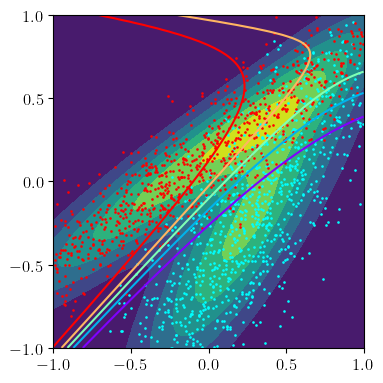

In [4]:
from exactdensity import ExactDensity
fexact = ExactDensity()

generate_test_data = True

if generate_test_data:
    
    sample_size = 62_500
    
    df = fexact.generate(N=sample_size)
    X  = torch.Tensor(df[['x1', 'x2']].to_numpy())
    Y  = torch.Tensor(df['y'].to_numpy())
    
    print(f'\n\tgenerated test_data: {sample_size} points\n')
else:    
    test_data_file = f'{BASE}/data/test_data.pth' 
    
    test_data = joblib.load(test_data_file)
    
    test_loader = dat.DataLoader(test_data, 
                                 batch_size=len(test_data))
    test_loader.reset()
    X, Y = next(test_loader)
    
    sample_size = len(X)
    
    # remove last dimension from Y: (n, 1) => (n, )
    Y = Y.squeeze()

    df = pd.DataFrame({'x1': X[:,0], 'x2': X[:, 1], 'y': Y})

    print(f'\n\tload test_data: {sample_size} points\n')

fexact.plot(dataframe=df[:10_000], fgsize=(4, 4))

## Generate signal or isolate from `test_data`

The signal points are those labeled $y = 1$.

In [5]:
generate_signal = True

if generate_signal:
    m = 18
    signal_size = 2**m
    leaf_size   = 2**(m-6)
    signal = fexact.rv1.rvs(signal_size)
else:
    signal = X[Y > 0.5].detach().numpy() # convert from tensor to numpy array
    
print(f'\t\tnumber of signal points: {len(signal)}')

		number of signal points: 262144


## Bin signal data using a KD-tree

Suppose we have $n$ points $\in \mathbb{R}^m$ that we wish to bin in $m$-D boxes. One way to do this is to use a data structure called a KD-tree. The latter can be visualized as a histogram in which the bins (i.e., leaves) are constructed by splitting each bin in two, such that each child bin has equal (or near equal) numbers of points. The algorithm is recursive in that the binary partitioning is applied to each of the two child bins of the parent and continues until the number of points in a given bin is $\le$ the desired bin (leaf) count. The bin is then referred to as a **leaf**. The algorithm is called **recursive binary partitioning** and is described informally below.

**Algorithm**
  1. Start with an $m$-D box (bin) containing all the points.
  2. Choose a dimension (`axis` in `numpy` jargon) from the sequence [0, 1,...m-1, 0, 1,....] along which to split the current bin. (The dimension chosen depends on the depth of the parent bin within the tree.)
  4. If the count in the current bin $\le$ the desired leaf count do not split the bin and call it a `leaf`, otherwise split the bin into two child bins and apply steps 2. and 3. to each child bin.
  5. Continue until all leaves have been constructed.

**Note**: The method `get_leaves()` of the class `KDTree` returns a list of leaves in *descending order* of estimated probability density.

A `leaf` of a `KDTree` object has the following attributes:
  1. ID: int - leaf identifier (ID = 0 for first leaf, ID = len(leaves)-1 for last leaf)
  1. points: (n, m)-ndarray - points in leaf
  2. bounds: (m, 2)-ndarray - limits of bounding box
  3. volume: float - volume of bounding box
  4. density: float - estimated probability density

In [10]:
importlib.reload(kdt) # reload module kdt if this cell is re-executed

# Note: the leaf size (that is, the number of points within leaf) will 
# be exactly equal to the desired leaf size if we choose the number 
# of signal points and the leaf size to be powers of 2.

# use a subset of the signal sample with sample size equal to a power of 2
# closest power of 2 s.t. signal_size <= len(signal)
if generate_signal:
    sig = signal # size is already a power of 2
else:
    # isolate signal (2**m = K => m = log(K) / log(2))
    m = int(np.floor(np.log(len(signal))/np.log(2))) 
    signal_size = 2**m
    
    # make the desired leaf count also a power of 2
    leaf_size = 2**(m-6)
    
    sig = signal[:signal_size] 

# build the 2D-tree using the "sig" sample
tree = kdt.KDTree(sig, leaf_size=leaf_size, store_nodeinfo=True)

# return the leaves (aka, bins) of the tree
leaves = tree.get_leaves()

print('number of leaves (aka bins):', len(leaves))
print()

print('leaf with highest density')
print(leaves[0])
print()

print('leaf with lowest density')
print(leaves[-1])

number of leaves (aka bins): 64

leaf with highest density
leaf: 0
  number of points:       4096
  density:           1.047e+00
  volume:            1.493e-02
        

leaf with lowest density
leaf: 63
  number of points:       4096
  density:           3.075e-03
  volume:            5.081e+00
        


In [75]:
depth, indices = tree.get_nodeinfo()
depth, indices

(array([0, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]),
 array([ 0,  1, 32,  2, 17, 33, 48,  3, 10, 18, 25, 34, 41, 49, 56,  4,  7,
        11, 14, 19, 22, 26, 29, 35, 38, 42, 45, 50, 53, 57, 60,  5,  6,  8,
         9, 12, 13, 15, 16, 20, 21, 23, 24, 27, 28, 30, 31, 36, 37, 39, 40,
        43, 44, 46, 47, 51, 52, 54, 55, 58, 59, 61, 62]))

Given our choices for `signal_size` and `leaf_size`, the count/leaf should be identical for all leaves. Check this.

In [11]:
check = True

if check:
    print(f'{'leaf':>5s}\t{'count':5s} {'number density':>10s}')
    for leaf in leaves:
        print(f'{leaf.ID:5d}\t{len(leaf.points):5d} {leaf.density:10.2e}')

 leaf	count number density
    0	 4096   1.05e+00
    1	 4096   1.03e+00
    2	 4096   9.94e-01
    3	 4096   9.79e-01
    4	 4096   9.43e-01
    5	 4096   9.41e-01
    6	 4096   9.12e-01
    7	 4096   9.01e-01
    8	 4096   8.81e-01
    9	 4096   8.75e-01
   10	 4096   8.73e-01
   11	 4096   8.40e-01
   12	 4096   8.37e-01
   13	 4096   8.36e-01
   14	 4096   8.19e-01
   15	 4096   8.15e-01
   16	 4096   7.76e-01
   17	 4096   7.69e-01
   18	 4096   7.23e-01
   19	 4096   7.22e-01
   20	 4096   6.92e-01
   21	 4096   6.91e-01
   22	 4096   6.86e-01
   23	 4096   6.80e-01
   24	 4096   5.60e-01
   25	 4096   5.55e-01
   26	 4096   5.11e-01
   27	 4096   5.09e-01
   28	 4096   4.71e-01
   29	 4096   4.66e-01
   30	 4096   4.65e-01
   31	 4096   4.64e-01
   32	 4096   3.54e-01
   33	 4096   3.53e-01
   34	 4096   2.95e-01
   35	 4096   2.86e-01
   36	 4096   1.01e-01
   37	 4096   9.07e-02
   38	 4096   8.16e-02
   39	 4096   7.98e-02
   40	 4096   7.33e-02
   41	 4096   7.00e-02
   42	 

### Plot KD-tree with $K = 2$

In [12]:
def plot_2dtree(leaves, points, 
                filename='2dtree.png', 
                xmin=-1, xmax=1, ymin=-1, ymax=1, 
                fgsize=(4.5, 4.4)):
    
    from matplotlib.patches import Rectangle

    # create a figure and add a single sub-plot
    fig = plt.figure(figsize=fgsize)
    nrows, ncols, index = 1, 1, 1
    ax  = fig.add_subplot(nrows, ncols, index)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
        
    tickmarks = np.linspace(xmin, xmax, 5)
    ax.set_xticks(tickmarks)
    ax.set_yticks(tickmarks)

    ax.set_xlabel('$x_1$', fontsize=18)
    ax.set_ylabel('$x_2$', fontsize=18)
    
    # normalize probability densities to interval [0, 1] 
    # so that each density corresponds to a color
    density     = [leaf.density for leaf in leaves]
    max_density = max(density)
    min_density = min(density)
    norm = colors.Normalize(vmin=min_density, vmax=max_density)

    # get desired colormap
    cmap = mp.colormaps['viridis']

    # loop over leaves and plot the bounding box of each leaf
    for leaf in leaves:
        
        (xmin, xmax), (ymin, ymax) = leaf.bounds
        xwidth = xmax - xmin
        ywidth = ymax - ymin

        # color bounding box of current leaf according to the density
        color = cmap(norm(leaf.density))
        rect = Rectangle((xmin, ymin), xwidth, ywidth, alpha=0.8, color=color)
        ax.add_patch(rect)

        # draw outline of bounding box
        ax.plot((xmin, xmax), (ymin, ymin), color='black', linewidth=0.5)
        ax.plot((xmax, xmax), (ymin, ymax), color='black', linewidth=0.5)
        ax.plot((xmax, xmin), (ymax, ymax), color='black', linewidth=0.5)
        ax.plot((xmin, xmin), (ymax, ymin), color='black', linewidth=0.5)

    # plot points
    x = points[:, 0]
    y = points[:, 1]
    ax.scatter(x, y, s=1, color='cyan')
    
    fig.tight_layout()
    
    plt.savefig(filename)
    plt.show()

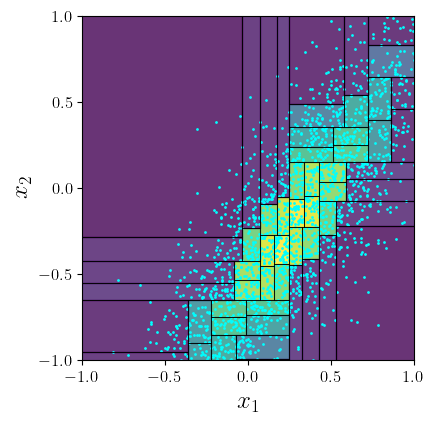

In [13]:
K = 2500
plot_2dtree(leaves, signal[:K])

## Exercise
**Note**: The 2D tensor of points $X$ and their associated labels $Y$ were extracted from `test_data` in a previous cell. **NB**: $X$ includes points from both signal and background.

(**15 points**)

 1. Using the model trained in `tutorial02`, compute $D(x)$ for *all* points $x \in X$ in  `test_data`. These values will be the weights $w(x)$, one for each point. Note that the shape of the tensor returned by the model is (n, 1), where n is the number of points since $X$ is a tensor of shape (n, 2). Therefore, you will need to `squeeze()` away dimension 1: `w = model(X).squeeze()` to change the shape from (n, 1) to (n, ), that is, to a 1D tensor. (If you need to change the tensor to a numpy array, do `w = w.detach().numpy()`.)
 2. From the `leaves` object, create a numpy array `S` of the probability densities of the signal.
 3. Using the method `find_leaf(x)` of object `tree` (which returns the leaf into which the point $x$ falls) create a numpy array $W$ of length `len(leaves)` in which each bin contains the summed weights of all points $x \in X$ that fall in that leaf. (*Hint*: to create a numpy array of length `len(leaves)`, initialized to zero, do `W = np.zeros(len(leaves))`.) A leaf is identified by its leaf identifier, the attribute, ID. Identifiers go from 0 for the leaf with the highest density to len(leaves)-1 for the leaf with the lowest density.
 4. Normalize $W$ so that the latter contains probability densities. (See Introduction for how this is done for the signal densities.) 
 5. Create a plot that compares the two arrays of densities.

**Optional** (**5 points**)
 Search the internet, or consult ChatGPT, for a statistical procedure to test whether the two arrays of densities are the same within statistical uncertainties. How would you account for the fact that there are statistical uncertainties in all the estimated densities?


# Solution

In [19]:
d = model(X).squeeze()

u = d.unsqueeze(dim=0)
w = d.unsqueeze(dim=1)

d.shape, u.shape, w.shape

(torch.Size([125000]), torch.Size([1, 125000]), torch.Size([125000, 1]))

In [20]:
# 1. compute D(x) for all x in X

D = model(X).squeeze()

# 2. get signal densities

S = [leaf.density for leaf in leaves]
S = np.array(S)

# compute estimate of uncertainties in signal densities
dS = S / np.sqrt(leaf_size)

print(S.shape, X.shape)

(64,) torch.Size([125000, 2])


In [22]:
# 3. compute densities using weighted test data

W  = np.zeros(len(S))
dW = np.zeros(len(S))

# compute densities
sample_size = D.sum() # effective sample size

for d, x in zip(D, X):

    leaf = tree.find_leaf(x)

    w = d / leaf.volume / sample_size
    
    # sum densities
    W[leaf.ID] += w
    
    # sum square of weights
    dW[leaf.ID] += w**2

# compute standard deviations
dW = np.sqrt(dW) 

# print(f'{"leaf":>5s} {"sig-density":>12s} {'w(x)*d(x)':>12s}')
# for i, (p, q) in enumerate(zip(S, W)):
#     print(f'{i:5d} {p:12.2e} {q:12.2e}')
print(W)

[1.07993412 1.08192635 0.97257775 1.00011468 0.95922226 0.94438946
 0.93154019 0.90807706 0.86855692 0.86058009 0.84226012 0.85057616
 0.89382184 0.79222739 0.78315496 0.84503782 0.7851187  0.75509155
 0.74627823 0.73570687 0.67174524 0.66620266 0.68850678 0.69536525
 0.54857814 0.55540752 0.50574094 0.51282012 0.45084471 0.48215032
 0.44887489 0.44898766 0.36642605 0.34975919 0.30262691 0.28798032
 0.09624527 0.08464452 0.082443   0.08259945 0.07231686 0.07209567
 0.06678283 0.06179563 0.05606987 0.0559881  0.0582884  0.05706491
 0.05150234 0.0545034  0.05219876 0.05613107 0.03881391 0.03699384
 0.03598766 0.03255657 0.03435136 0.02708133 0.02265714 0.0249182
 0.00850394 0.00797966 0.00336439 0.00313909]


In [23]:
# 4. here we create three different plots

def plot_results1(p, q, dp=None, dq=None,
                  filename='results1.png',
                  xmin=0, xmax=1.4, ymin=0, ymax=1.4,
                  fgsize=(4.5, 4.5)):
    
    # create a figure and add a single sub-plot
    fig = plt.figure(figsize=fgsize)
    
    nrows, ncols, index = 1, 1, 1
    ax = fig.add_subplot(nrows, ncols, index)
    
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel('signal densities', fontsize=16)
    ax.set_ylabel('predicted signal densities', fontsize=16)
    
    ax.plot((xmin, xmax), (ymin, ymax), color='red')

    ax.errorbar(x=p, y=q, xerr=dp, yerr=dq,
                fmt='o', # no lines connecting points
                color='steelblue',
                markerfacecolor='black',
                markeredgecolor='black',
                markersize=4,
                markeredgewidth=1)
    ax.grid()
    
    fig.tight_layout()
    plt.savefig(filename)
    plt.show()

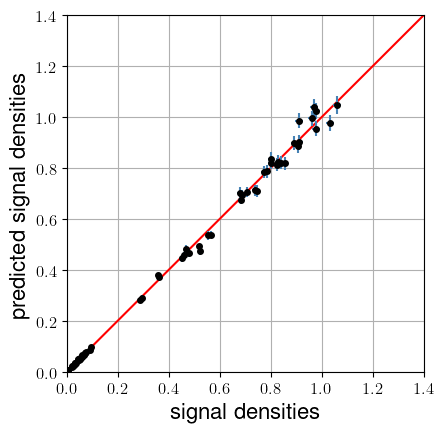

In [16]:
plot_results1(p=S, q=W, dp=dS, dq=dW)

In [24]:
def plot_results2(p, q, dq, 
                  filename='results.png', 
                  fgsize=(6, 4)):

    fig = plt.figure(figsize=fgsize)
    
    nrows, ncols, index = 1, 1, 1
    ax = fig.add_subplot(nrows, ncols, index)

    xmin, xmax = 0, len(p)
    ymin, ymax = 0, 1.4
    
    x = np.linspace(xmin, xmax-1, len(p))
    
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_xlabel('leaf ID', fontsize=18)
    ax.set_ylabel('density $(dp/dv)$', fontsize=18)
    
    ax.hist(x, bins=len(p), weights=p, alpha=0.8, histtype='bar')

    ax.errorbar(x, q, dq, 
                fmt='o',  # no lines connecting points
                color='black',
                markerfacecolor='black', 
                markeredgecolor='black', 
                markersize=4,
                markeredgewidth=1)
  
    fig.tight_layout()
    
    plt.savefig(filename)
    plt.show()

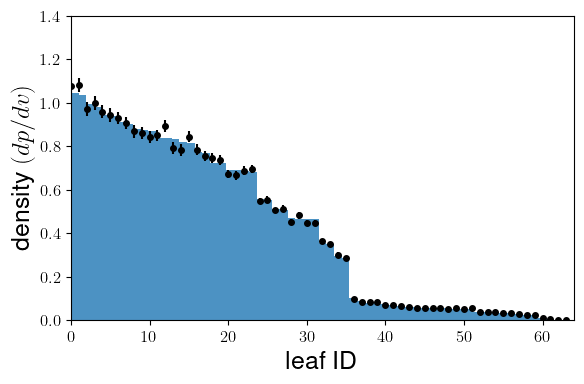

In [25]:
plot_results2(S, q=W, dq=dW)

In [26]:
def plot_results3(p, q, dp=None, dq=None,
                  filename='results2.png',
                  fgsize=(6, 4)):
    
    fig = plt.figure(figsize=fgsize)

    nrows, ncols, index = 1, 1, 1
    ax = fig.add_subplot(nrows, ncols, index)

    xmin, xmax = 0, len(p)
    ymin, ymax = 0, 1.4
    
    x = np.linspace(xmin, xmax-1, len(p))
    
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel('leaf ID', fontsize=16)
    ax.set_ylabel('density $(dp/dv)$', fontsize=16)
    
    if type(dp) == type(None):
        ax.hist(x, bins=len(p), weights=p, alpha=0.4, histtype='bar',
        label='$s(x)$')
    else:
        ax.fill_between(x, p-dp, p+dp, color="blue", alpha=0.5,
                        label="signal density error band")
        
    ax.errorbar(x, y=q, yerr=dq,
                fmt='o', # no lines connecting points
                color='steelblue',
                markerfacecolor='black',
                markeredgecolor='black',
                markersize=4,
                markeredgewidth=1, 
                label='densities from weighted data')
    ax.legend()
    
    fig.tight_layout()
    plt.savefig(filename)
    
    plt.show()

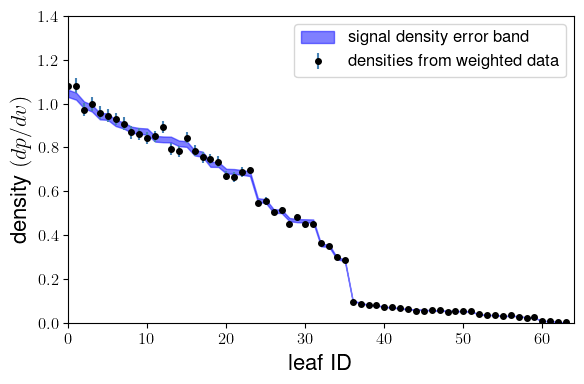

In [27]:
plot_results3(p=S, q=W, dp=dS, dq=dW)

## Optional: A thumbnail sketch of frequentist hypothesis testing

Our goal is to answer the question: 

*Are the two lists of densities the same?* 

To proceed, this question needs to be made precise so that it can be answered precisely. We'll do  so from a **frequentist** perspective. What this means is that the statistical procedure to be used will be based on the interpretation of probability as a **relative frequency**, that is, the ratio of the number of times a particular kind of event occurs over the total number of events. Think of tossing a coin $N$ times. The possible events are either heads or tails. (We ignore the events in which the coin lands on its edge.) If $n$ is the number of times heads appears, then the probability of heads according to the relative frequency interepretation is the ratio $n / N$ in the limit $N \rightarrow \infty$.  

From a frequentist perspective, the question and its answer can be made precise using the following procedure (called a **hypothesis test**):

  2. Construct a measure $\lambda(S, W)$ of the *dissimilarity* of the lists $S$ and $W$ such that large values of $\lambda(S, W)$ indicate at least one large difference between the two lists. The quantity $\lambda$ is called a **test statistic**.
  3. Specify a **null hypothesis**, denoted by $H_0$, about the two lists. Usually, null hypotheses state that there is nothing interesting in the data, that is, there is no signal or anomaly. In our case this would mean that there is no difference between the two lists.
  4. Compute the probability density $p(\lambda| H_0)$ of $\lambda$ given (that is, assuming) that $H_0$ is true. This will tell us the values of $\lambda$ to be expected when the lists agree. The intuition here is that if the value of $\lambda$ computed using the lists $S$ and $W$ is larger than expected this would tend to cast doubt on the hypothesis $H_0$. This is made precise as follows.
  6. Choose a threshold $t$ on $\lambda$ above which we are prepared to *reject* the null hypothesis $H_0$. Another way to arrive at the same place is to choose a small probability $\alpha$, called the **size or level of the test**; compute the so-called p-value $p = \text{Pr}(\lambda > \lambda_0|H_0)$, where $\lambda_0$ is computed using the lists $S$ and $W$ above, and reject $H_0$ if $p < \alpha$.  If the null hypothesis is rejected, we are declaring that there is a statistically significant difference between the two lists given the chosen threshold on $\lambda$. If $H_0$ is *not* rejected this does not mean we are accepting the null hypothesis! It simply means that the available data are insufficient to reject that hypothesis. It is then a matter of choice whether you accept a null hypothesis that has *not* been rejected. (Yes, I know, this all sounds terribly backwards! But this is a very widely used protocol in physics and medical research. In medical research, $\alpha$ is often taken to be $5\times 10^{-2}$, which, alas, is a very weak criterion for rejecting a null hypothesis--e.g., a new drug does not work, while in particle physics $\alpha = 2.7 \times 10^{-7}$! It is also the norm in both fields to report the p-values  because the latter provides more information about the strengh of evidence against the null hypothesis than simply reporting that the null hypothesis has or has not been rejected.)

### Test statistic 
Here is a plausible measure of dissimilarity, 
\begin{align}
    \lambda(S, W) & = \sum_{i=1}^N \left(\frac{S_i - W_i}{\sigma_{W_i}}\right)^2,
\end{align}
where $N$ is the number of leaves (i.e., bins) and $\sigma_{W_i}^2$ is the estimated variance of $W_i$ in bin $i$. (We're neglecting the uncertainty in $S$.)

### $p(\lambda | H_0)$
Since computing $p(\lambda | H_0)$ is intractable, we'll approximate the latter by histogramming values of $\lambda$. But to do so a large sample of pairs of lists $\{ (S^{(j)}, W^{(j)})\}_{j=1}^T$ must be generated, where by construction the lists match each other modulo statistical fluctuations. But this requires access to the exact function $D(x)$, which, unfortunately, we do not have! Instead, we'll use realizations of the list $S$ as a proxy for $W$: instances of $S$ will be generated in pairs; one will be used for $S$ and the other for $W$.


### Package the code in earlier cells into a single function

In [30]:
from random import choices

K = 20

I = np.arange(K)

J = np.array([int(x) for x in choices(I, k=K)])

I, J

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 array([ 7, 16,  7,  3,  2,  2,  2, 19,  5,  5,  9,  3, 12,  4,  6, 18, 18,
         1,  0, 10]))

In [21]:
from random import choices
   
def generate_bootstrap_indices(K):
    I = np.arange(K)
    J = np.array([int(x) for x in choices(I, k=K)])
    return J
    
def simulate_exact_classifier(X, Y, tree):
    
    # 1. create a bootstrap sample (sampling with replacement)
    J = generate_bootstrap_indices(len(X))
    x, y = X[J], Y[J]
    
    # 2. a perfect classifier would weight the test data
    #    points so that the weighted points would match
    #    the signal exactly
    signal = x[y > 0.5].detach().numpy()
    nsignal = len(signal)
    
    # 3. compute densities
    W = np.zeros(len(tree))
    dW = np.zeros(len(tree))
    
    for point in signal:
        
        leaf = tree.find_leaf(point)

        w = 1 / leaf.volume / nsignal
        
        W[leaf.ID] += w
        dW[leaf.ID] += w**2
        
    dW = np.sqrt(dW)
    
    return W, dW

### Plot simulated densities

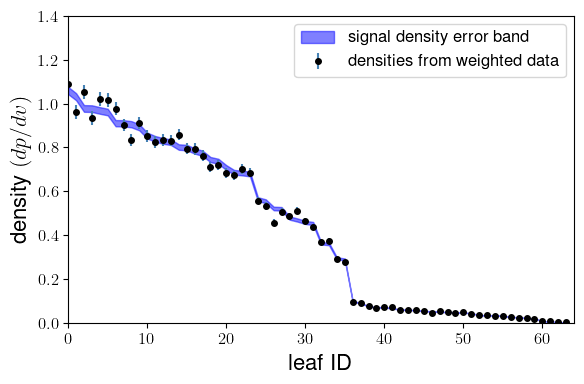

In [23]:
w, dw = simulate_exact_classifier(X, Y, tree)

plot_results3(p=S, q=w, dp=dS, dq=dw, filename='bootstrapped.png')

In [24]:
def gof(p, q, dq):
    pq = (p - q) / dq
    return float( (pq**2).sum() )

In [25]:
from time import time

T = 400
t = []
start = time()
for i in range(T):
    
    if i % 10 == 0:
        print(f'\rsim: {i:10d}', end='')

    w, dw = simulate_exact_classifier(X, Y, tree)
    
    t.append( gof(S, w, dw) )
    
end = time()

time_per_sim = 1e3*(end-start)/T

print(f'\ntime/simulation: {time_per_sim:5.1f} ms')

t = np.array(t)

sim:        390
time/simulation: 122.8 ms


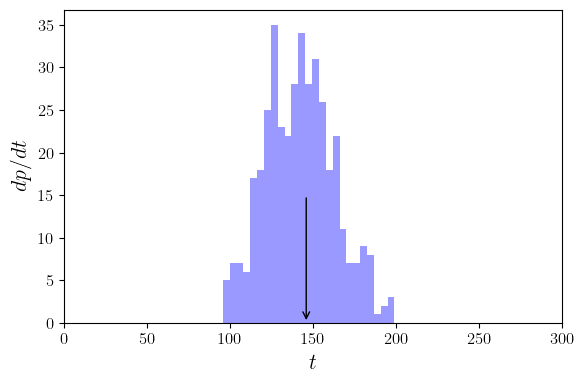

In [41]:
def plot_H0(x, t0,
            xbins=25, xmin=0, xmax=300, 
            ymin=0, ymax=-1,
            filename='H0.png', fgsize=(6, 4)):
    
    fig = plt.figure(figsize=fgsize)

    nrows, ncols, index = 1, 1, 1
    ax = fig.add_subplot(nrows, ncols, index)

    ax.set_xlim(xmin, xmax)
    if ymax > 0:
        ax.set_ylim(ymin, ymax)
        
    ax.set_xlabel('$t$', fontsize=16)
    ax.set_ylabel('$dp/dt$', fontsize=16)

    ax.hist(x, bins=xbins, alpha=0.4, color='blue')

    ax.annotate("", xytext=(t0, 0), xy=(t0, 15),
                arrowprops=dict(arrowstyle="<-"))
    
    fig.tight_layout()
    plt.savefig(filename)
    plt.show()

# --------------------------------------------------
t0 = gof(S, W, dW)

plot_H0(t, t0)